# 1

Максимальная ошибка: 2.58e-04


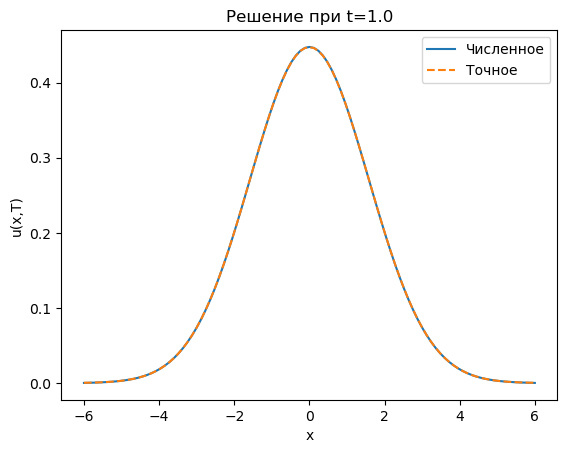

Порядок сходимости: 2.01 (теоретический 2.00)


In [5]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# Параметры задачи
L = 6.0       
T = 1.0         
N = 100        
tau = 0.01       
h = 2*L / N   

sqrt3 = np.sqrt(3)
c = np.array([(3 - sqrt3)/6, (3 + sqrt3)/6])
A = np.array([[ (3 - sqrt3)/6, 0 ],
              [ sqrt3/3, (3 - sqrt3)/6 ]]) 
b = np.array([0.5, 0.5])


x = np.linspace(-L, L, N+1)


u0 = np.exp(-x**2)


def exact_solution(x, t):
    return np.exp(-x**2 / (1 + 4*t)) / np.sqrt(1 + 4*t)


diag = np.ones(N+1) * (-2 / h**2)
off_diag = np.ones(N) / h**2
Lap = sp.diags([off_diag, diag, off_diag], [-1, 0, 1], format='csc')

I = sp.eye(N+1, format='csc')


u = u0.copy()
t = 0.0
while t < T:
    if t + tau > T:
        tau = T - t
    
    M1 = I - tau * A[0,0] * Lap 
    rhs1 = tau * Lap.dot(u)
    k1 = spla.spsolve(M1, rhs1)
    
    M2 = I - tau * A[1,1] * Lap  
    rhs2 = tau * Lap.dot(u + A[1,0]*k1)
    k2 = spla.spsolve(M2, rhs2)
    
    u += b[0]*k1 + b[1]*k2
    
    t += tau

u_exact = exact_solution(x, T)
error = np.max(np.abs(u - u_exact))
print(f"Максимальная ошибка: {error:.2e}")

plt.plot(x, u, label='Численное')
plt.plot(x, u_exact, '--', label='Точное')
plt.legend()
plt.xlabel('x')
plt.ylabel('u(x,T)')
plt.title(f'Решение при t={T}')
plt.show()

def compute_error(N, L=6.0, T=1.0):
    h = 2*L / N
    tau = 0.01 * (h / (2*L/100))**(2/3)
    
    x = np.linspace(-L, L, N+1)
    u0 = np.exp(-x**2)
    
    diag = np.ones(N+1) * (-2 / h**2)
    off_diag = np.ones(N) / h**2
    Lap = sp.diags([off_diag, diag, off_diag], [-1, 0, 1], format='csc')
    
    I = sp.eye(N+1, format='csc')  
    
    u = u0.copy()
    t = 0.0
    while t < T:
        if t + tau > T:
            tau_step = T - t
        else:
            tau_step = tau
        
        M1 = I - tau_step * A[0,0] * Lap
        M2 = I - tau_step * A[1,1] * Lap
        
        rhs1 = tau_step * Lap.dot(u)
        k1 = spla.spsolve(M1, rhs1)
        
        rhs2 = tau_step * Lap.dot(u + A[1,0]*k1)
        k2 = spla.spsolve(M2, rhs2)
        
        u += b[0]*k1 + b[1]*k2
        t += tau_step
    
    return np.max(np.abs(u - exact_solution(x, T)))

errors = []
Ns = [50, 100, 200]
for N in Ns:
    errors.append(compute_error(N))

p = np.log2(errors[0]/errors[1])
print(f"Порядок сходимости: {p:.2f} (теоретический 2.00)")

Используем краевые условие Дирихле: U(-L, t) = U(L, t) = 0, оно согласуются с поведением решения, которое быстро убывает на бесконечности и сохраняют второй порядок пространственной аппроксимации.

так как порядок апроксимации по времени 3, а по пространству 2, то $\tau$ ~ $h^{2/3}$

# 2

Исходные краевые условия некорректны.

Система уравнений имеет характеристики, распространяющиеся в противоположных направлениях. После замены переменных:

w=u+v (идет вправо)

z = u-v (идет влево)

корректные краевые условия должны задаваться следующим образом:
На левой границе условие для z, на правой границе условие для w

Заданное условие на левое границе - на z корректно, а условие на правое границе аналогично w(1, t) = z(1, t),

нужно использовать свободное граничное условие для w